Utilizando la implementación vista en clase para la integración por medio de Cuadratura Gaussiana.

Función para calcular los puntos de muestreo y los pesos según la cantidad de subregiones que se deseen utilizar

In [48]:
import numpy as np

def gaussxw(N):

	"""
    Calcula los puntos de muestreo y los pesos de la cuadratura de Gauss.

    La cuadratura de Gauss se utiliza para aproximar integrales definidas
    mediante una suma ponderada de valores de la función en puntos específicos.

    Args:
		N (int): Número de puntos de muestreo y pesos a calcular, corresponde al número de subregiones a usar.

    Returns:
		Output (tuple):
			x (numpy.ndarray): Puntos de muestreo de la cuadratura de Gauss.
			w (numpy.ndarray): Pesos correspondientes a cada punto de muestreo.
	
	Example:
		>>> x, w = gaussxw(5)
		>>> print(x)
		>>> print(w)
    """

	# SE OPTA POR MANTENER LA RUTINA TAL Y COMO SE ENCUENTRA EN EL JUPYTER ORIGINAL.
	# Aproximación inicial
	a = np.linspace(3, 4 * (N - 1), N) / ((4 * N) + 2)
	# Note código vectorial aquí
	x = np.cos(np.pi * a + 1 / (8 * N * N * np.tan(a)))

	# Ahora calculamos las raíces de los polinomios utilizando el método de Newton
	# Este es un tema que veremos la próxima semana!
	# De momento, puede ignorar el siguiente flujo de control con el "while" y saber que esto 
	# devuelve los puntos de muestreo obtenidos con los polinomios de Legendre
	epsilon = 1e-15
	delta = 1.0
	while delta > epsilon:
		p0 = np.ones(N, dtype = float)
		# Deep copy
		p1 = np.copy(x)
		for k in range(1, N):
			p0, p1 = p1, ((2 * k + 1) * x * p1 - k * p0) / (k + 1)
		dp = (N + 1) * (p0 - x * p1) / (1 - x * x)
		dx = p1 / dp
		x -= dx
		delta = np.max(np.abs(dx))

	# Ahora calculamos los pesos
	w = 2 * (N + 1) * (N + 1)/(N * N * (1 - x * x) * dp * dp)

	# Note que la función devuelve un tuple
	return x,w

Función para escalar los puntos de muestreo y los pesos fuera del intervalo de ortogonalidad de los polinomios de Legendre

In [49]:
def gaussxwab(a, b, x, w):
	"""
    Transforma los puntos y pesos de la cuadratura de Gauss
    desde el intervalo [-1, 1] al intervalo [a, b].

    Args:
		a (float): Límite inferior del nuevo intervalo de integración.
		b (float): Límite superior del nuevo intervalo de integración.
		x (numpy.ndarray): Puntos de muestreo en el intervalo [-1, 1].
		w (numpy.ndarray): Pesos asociados a los puntos de muestreo en [-1, 1].

    Returns:
		Output (tuple):
			x_escalado (numpy.ndarray): Puntos de muestreo transformados al intervalo [a, b].
			w_escalado (numpy.ndarray): Pesos transformados correspondientes a los nuevos puntos de muestreo en el intervalo [a, b].

	Example:
		>>> x_escalado, w_escalado = gaussxw(1,3,x,w)
		>>> print(x_escalado)
		>>> print(w_escalado)
    """
	# SE OPTA POR MANTENER LA RUTINA TAL Y COMO SE ENCUENTRA EN EL JUPYTER ORIGINAL.
	# Obtenido de pag 168 Newman)
	# Note que esta función está escrita a-la-Pitón: si funciona bueno; si no, es culpa suya.
	return 0.5 * (b - a) * x + 0.5 * (b + a), 0.5 * (b - a) * w

Función para realizar la integración por medio de  Cuadratura Gaussiana, esta toma todos los datos necesarios de la integral a resolver (integrando, límite inferior y superior) y los datos para la aproximación (número de subregiones y  las funciones anteriores).

In [50]:
def int_cuadraGauss(integrando, x_inf, x_sup, steps, noEscalado = gaussxw, escalado = gaussxwab ):
	"""
    Calcula la integral de una función utilizando la cuadratura de Gauss con polinomio ortogonal (Legendre).

    Esta función evalúa una integral definida en el intervalo [x_inf, x_sup]
    mediante la cuadratura de Gauss, escalando los puntos y pesos de la cuadratura 
    de Gauss mediante polinomios ortogonales al intervalo deseado. Por defecto se utiliza 
	polinomios de Legendre.

    Args:
		integrando (callable): Función a integrar. Debe aceptar un array de puntos como entrada.
		x_inf (float): Límite inferior del intervalo de integración.
		x_sup (float): Límite superior del intervalo de integración.
		steps (int): Número de puntos de muestreo a utilizar en la cuadratura.
		noEscalado (callable): Función que calcula los puntos y pesos en el intervalo [-1, 1]. Por defecto, utiliza `gaussxw`.
		escalado (callable): Función que transforma los puntos y pesos al intervalo [x_inf, x_sup]. Por defecto, utiliza `gaussxwab`.

    Returns:
		output (float): Aproximación de la integral definida de `integrando` en el intervalo [x_inf, x_sup].
	
	Example:
		>>> # Integrar x**6 -(x**2)*sin(2*x) en el intervalo [1,3]
		>>> def integrando(x):
		>>>		return x**6 -(x**2)*np.sin(2*x)

		>>> int_cuadraGauss(integrando,1,3)
    """
	
	x_sin_escalar, w_sin_escalar = noEscalado(steps)
	x , w = escalado(x_inf,x_sup,x_sin_escalar,w_sin_escalar)

	I = np.dot(integrando(x),w)
	return I

# Aquí comienza la solución realmente

In [51]:
import sympy as smp

In [52]:
z, t = smp.symbols(r"z,t")

Z = t/(1+t)
Z

t/(t + 1)

In [53]:
Zp = smp.diff(Z,t)
Zp.simplify()

(t + 1)**(-2)

In [54]:
sol = smp.solve(smp.Eq(z,Z), t)[0]
sol

-z/(z - 1)

In [55]:
smp.diff(sol,z).simplify()

(z - 1)**(-2)

In [56]:
def integrando(z):
	return np.exp(-(z**2)/(z-1)**2)/((z-1)**2)

In [59]:
N_list = np.arange(2,52,2)
I_list = np.zeros(len(N_list))

for i in range(len(N_list)):
	I_list[i] = int_cuadraGauss(integrando,0.0,1.0,N_list[i])

Text(0, 0.5, 'Aproximación $\\int_{0}^{+ \\infty} e^{-t^2} dt$')

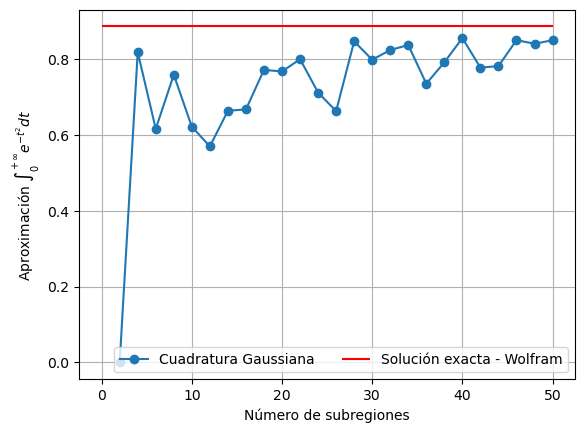

In [60]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1,1)
ax.plot(N_list,I_list, "-o", label = "Cuadratura Gaussiana")
ax.hlines(np.sqrt(np.pi)/2,0,np.max(N_list), color = "red" , label= "Solución exacta - Wolfram")
ax.grid()
ax.legend(loc = 'lower right',ncol =2)

ax.set_xlabel("Número de subregiones")
ax.set_ylabel("Aproximación " + r"$\int_{0}^{+ \infty} e^{-t^2} dt$")